In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import jax
import jax.numpy as jnp

# Configure JAX to use only the CPU
# jax.config.update('jax_platform_name', 'cpu') 

print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]

import jax.experimental.layout as _layout
if not hasattr(_layout, 'DeviceLocalLayout'):
        # Provide a minimal alias so orbax can import function annotations\n",
        _layout.DeviceLocalLayout = _layout.Layout
        print('Patched jax.experimental.layout.DeviceLocalLayout ->', getattr(_layout, 'DeviceLocalLayout'))
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from flax.training import checkpoints
from pinn.utils import initial_loss
from tqdm.notebook import trange



jax: 0.7.2
devices: [CudaDevice(id=0)]
Patched jax.experimental.layout.DeviceLocalLayout -> <class 'jax._src.layout.Layout'>


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/venk_1/lambda_1000000_50/checkpoint_10000


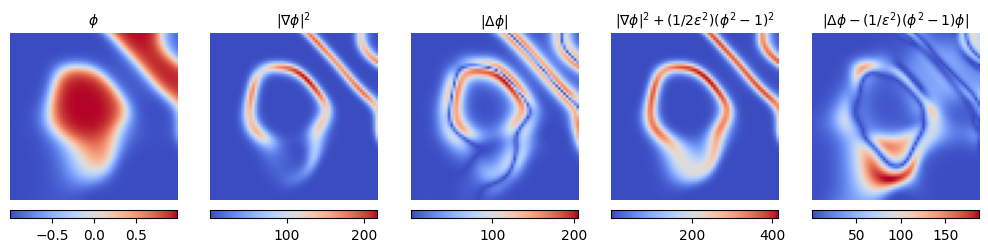

In [40]:
from pinn.plot import visualize_physics_loss
from mpl_toolkits.axes_grid1 import make_axes_locatable

GRID_SIZE = 64
lambda_1 = 1000000
lambda_2 = 50
epsilon = 0.05
shape = "venk_1"
step = 10000
data_type = "1115"

comp_list = ["phi", "grad_norm2", "laplacian", "tension", "residual"]
title_map = {
    "phi": r"$\phi$",
    "grad_norm2": r"$|\nabla \phi|^2$",
    "laplacian": r"$|\Delta \phi|$",
    "tension": r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$", 
    "residual": r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$", 
}


# ckpt_path = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/clean/sphere/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
# ckpt_path = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/combine/a01_m07/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
# ckpt_path = os.path.abspath(f"../outputs/logs/{shape}/combine/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
ckpt_path = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
print(ckpt_path)
ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)

n = len(comp_list)
fig = plt.figure(figsize=(2.5*n, 2.5*1))

for i, component in enumerate(comp_list):
    ax = fig.add_subplot(1, n, i + 1)

    img = visualize_physics_loss(ax, epsilon=epsilon, checkpoint=ckpt_data, component=component, 
                           # grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z", no_label=True)
                           grid_size=GRID_SIZE, slice_index=36, axis="x", no_label=True)
    ax.set_title(title_map.get(component, component), fontsize=10)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.1)
    cbar = plt.colorbar(img, cax=cax, orientation="horizontal")


In [41]:
import matplotlib.pyplot as plt

def visualize_binary_mask_slice(cryoET_data, threshold=0.8, axis="z", slice_index=None):
    binary_mask = (cryoET_data > threshold).astype(float)

    if slice_index is None:
        slice_index = binary_mask.shape[0] // 2

    if axis == "z":
        img = binary_mask[:, :, slice_index]
    elif axis == "y":
        img = binary_mask[:, slice_index, :]
    elif axis == "x":
        img = binary_mask[slice_index, :, :]
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.colorbar(label="Binary mask")
    plt.title(f"Binary mask ({axis}-slice @ {slice_index})")
    plt.axis("off")
    plt.show()


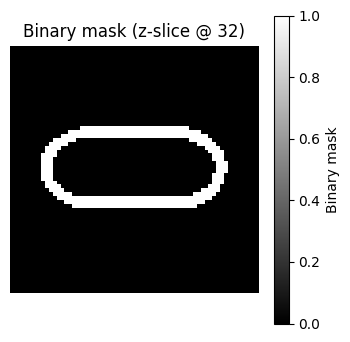

In [44]:
GRID_SIZE = 64
shape = "biconcave"
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
visualize_binary_mask_slice(cryoET_data, threshold=0.5, axis="z")

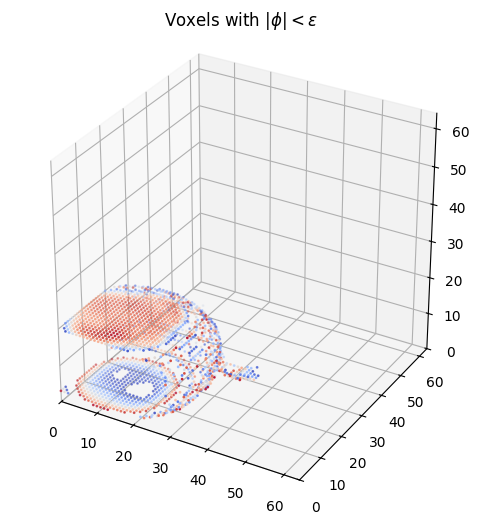

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.model import PINN

GRID_SIZE = 64
shape = "biconcave"
lambda_1 = 1000000
lambda_2 = 0
step = 50000

checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# normalized coordinate grid
x = np.linspace(-1, 1, GRID_SIZE)
y = np.linspace(-1, 1, GRID_SIZE)
z = np.linspace(-1, 1, GRID_SIZE)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
grid_points = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1)

model = PINN()
params = checkpoint["state"]["params"]
phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))

tomogram = np.asarray(phi_fn(grid_points)).reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE)
tomogram = tomogram[20:64, 20:64, 20:64]

zero_thre = 0.1
mask = np.abs(tomogram) < zero_thre

coords = np.argwhere(mask)
values = tomogram[mask]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")
ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)
ax.set_zlim(0, GRID_SIZE)
ax.scatter(coords[:,2], coords[:,1], coords[:,0], s=1, c=values, cmap="coolwarm")
ax.set_box_aspect([1,1,1])
ax.set_title(r"Voxels with $|\phi| < \epsilon$")
plt.show()
